In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import copy
import mytools
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from scipy import stats

# device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:
# Select run number
run="1"


In [3]:
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/unscaled/2019_pass2_tritrig.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/unscaled/2019_pass2_phiKK.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/unscaled/2019_pass2_wab.pk')
df_wab['PhiKK'] = 0.0 # Add label
df_data = pd.read_pickle('/Users/mghrear/data/ML_data/2019_pass2/unscaled/2019_pass2_data_full.pk')



# Make MC test set
# MUST BE CONSISTENT with BDT.ipynb and ANN.ipynb to avoid data leaks!!
tritrig_test = df_tritrig[50000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[6000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[5000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
Y_test = df_test['PhiKK']

# Make data set
X_final = df_data


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_12939/4168281839.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_12939/4168281839.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_12939/4168281839.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [4]:
len(df_data)

16751850

In [5]:
# Load trained models
MLP = mytools.Classifier(in_features=X_final.shape[1]).to(device)
MLP.load_state_dict(torch.load( "/Users/mghrear/data/ML_data/2019_pass2/models/pretrained_classifier_2019_pass2_run"+str(run)+"_unscaled.pt", map_location=device))
MLP.eval()

ANN = mytools.Classifier(in_features=X_final.shape[1]).to(device)
ANN.load_state_dict(torch.load( "/Users/mghrear/data/ML_data/2019_pass2/models/classifier_adv_2019_pass2_run"+str(run)+"_unscaled.pt", map_location=device))
ANN.eval() 

BDT = joblib.load('/Users/mghrear/data/ML_data/2019_pass2/models/BDT_2019_pass2_unscaled.pkl')


In [6]:
# Get model predictions
test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)) )
test_loader = DataLoader(test_dataset, batch_size=2000, shuffle=False)
final_dataset = TensorDataset(torch.from_numpy(X_final.to_numpy().astype(np.float32)) )
final_loader = DataLoader(final_dataset, batch_size=2000, shuffle=False)

MLP_pred = mytools.test_clas(test_loader, MLP, device)
MLP_pred=torch.sigmoid(torch.tensor(MLP_pred)).numpy()

ANN_pred = mytools.test_final(test_loader, ANN, device)
ANN_pred=torch.sigmoid(torch.tensor(ANN_pred)).numpy()

ANN_pred_final = mytools.test_final(final_loader, ANN, device)
ANN_pred_final=torch.sigmoid(torch.tensor(ANN_pred_final)).numpy()

BDT_pred = BDT.predict_proba(X_test)[:,1]  # BDT uses unscaled features
BDT_pred_final = BDT.predict_proba(X_final)[:,1]  # BDT uses unscaled features

# Add predictions to dataframe 
df_test['MLP'] = MLP_pred
df_test['ANN'] = ANN_pred
df_test['BDT'] = BDT_pred

# Add invariant mass to dataframe
df_test['InvM'] = mytools.get_InvM(df_test)

df_data['ANN'] = ANN_pred_final
df_data['BDT'] = BDT_pred_final
df_data['InvM'] = mytools.get_InvM(df_data)

In [7]:
# Split into tritrig, wab, background and phiKK dataframes
test_df_tritrig = df_test[df_test['type']=="tritrig"].reset_index(drop=True)
test_df_phiKK = df_test[df_test['type']=="phiKK"].reset_index(drop=True)
test_df_wab = df_test[df_test['type']=="wab"].reset_index(drop=True)
test_df_bkg = pd.concat([test_df_tritrig,test_df_wab])

# Combine dfs according to expected proportions 1470:228:1 (tritrig:wab:phiKK)
# Binding constraint: floor(len(test_df_wab) / 228) = floor(10422/228) = 45
k = min(len(test_df_tritrig) // 5129, len(test_df_wab) // 791, len(test_df_phiKK) // 1)
n_tritrig, n_wab, n_phiKK = 5129 * k, 791 * k, 1 * k
print(f"k={k}  tritrig={n_tritrig}  wab={n_wab}  phiKK={n_phiKK}  total={n_tritrig+n_wab+n_phiKK}")

df_test_combined = pd.concat(
    [test_df_tritrig.iloc[:n_tritrig], test_df_wab.iloc[:n_wab], test_df_phiKK.iloc[:n_phiKK]],
    ignore_index=True, sort=False
)


k=13  tritrig=66677  wab=10283  phiKK=13  total=76973


In [8]:


ANN_selection = np.percentile(test_df_bkg['ANN'], 99.5)
BDT_selection = np.percentile(test_df_bkg['BDT'], 99.5)

# Apply ANN to data

chi2/ndf = 25505.5/99 = 257.631,  p = 0.000e+00


Text(0.02, 0.95, '$\\chi^2$/ndf = 257.631,  p = 0.000e+00')

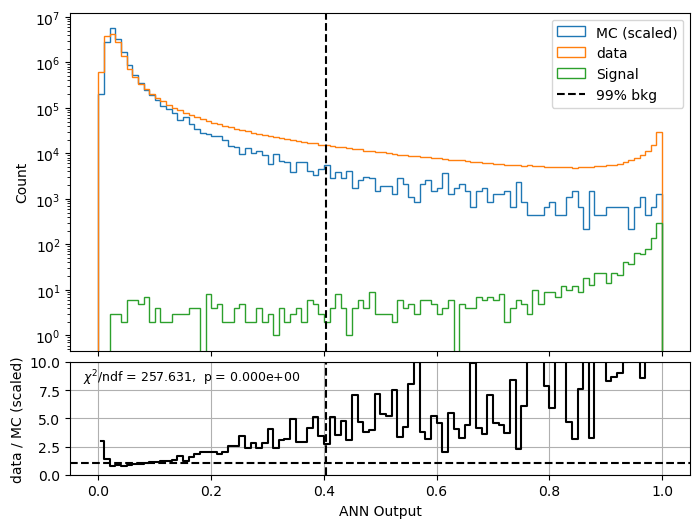

In [9]:
bins = np.arange(0,1.01,0.01)

mc   = df_test_combined['ANN'].to_numpy()
data = df_data['ANN'].to_numpy()
sig = test_df_phiKK['ANN'].to_numpy()


# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

mc_scale = data_counts.sum() / mc_counts.sum()

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts * mc_scale,
                  out=np.full_like(data_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

# Chi-squared test (only bins where mc_counts > 0)
mask = mc_counts > 0
chi2_vals = (data_counts[mask] - mc_counts[mask] * mc_scale)**2 / (data_counts[mask] + mc_scale**2 * mc_counts[mask])
chi2  = chi2_vals.sum()
ndf   = mask.sum() - 1  # -1 for normalization constraint
pval  = stats.chi2.sf(chi2, ndf)
print(f"chi2/ndf = {chi2:.1f}/{ndf} = {chi2/ndf:.3f},  p = {pval:.3e}")

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: MC scaled to match data total events ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, weights=np.full(len(mc), mc_scale), label='MC (scaled)')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(sig, bins=bins, histtype='step', label='Signal')

ax_top.set_ylabel('Count')
ax_top.set_yscale('log')
ax_top.axvline(x=ANN_selection, color='k', linestyle='--', label ="99% bkg")
ax_top.legend()

# --- Bottom: data / scaled MC ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.grid(True)
ax_bot.set_ylabel('data / MC (scaled)')
ax_bot.set_xlabel('ANN Output')
ax_bot.axhline(y=1, color='k', linestyle='--')
ax_bot.set_ylim(0, 10)
ax_bot.axvline(x=ANN_selection, color='k', linestyle='--', label ="selection line")
ax_bot.text(0.02, 0.95, f'$\\chi^2$/ndf = {chi2/ndf:.3f},  p = {pval:.3e}',
            transform=ax_bot.transAxes, fontsize=9, va='top')

In [10]:
QualCuts = {
    'pos_E_Ecal_low': 0.6,
    'pos_Px_low': -0.06,
    'ele_Ecal_z_low': 1448.6,
    'ele_Ecal_y_low': -85.0,
    'ele_Ecal_y_high': 85.0,
}

Text(0, 0.5, 'Count')

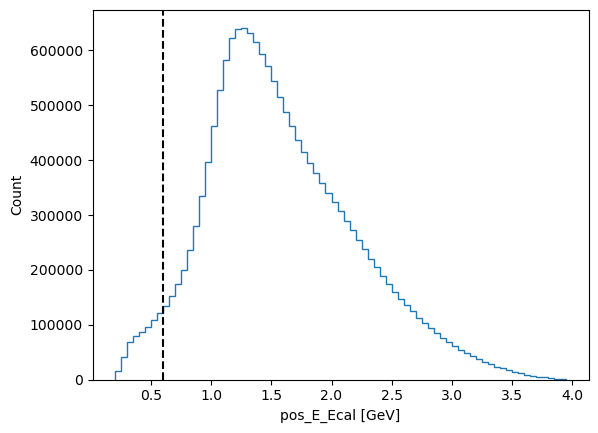

In [11]:
plt.hist(df_data.pos_E_Ecal, bins = np.arange(.2,4,0.05),histtype='step')
plt.axvline(x=QualCuts['pos_E_Ecal_low'], color='k', linestyle='--', label ="selection line")
plt.xlabel('pos_E_Ecal [GeV]')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

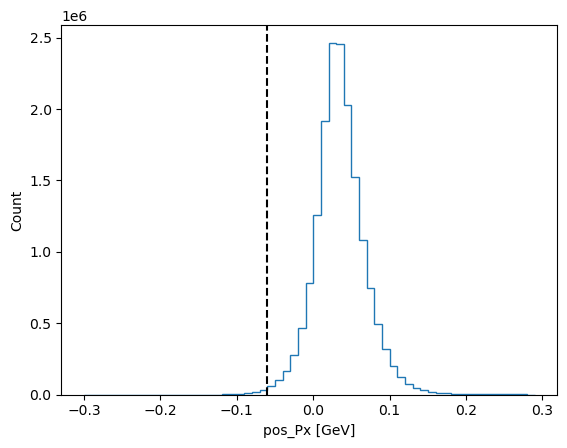

In [12]:
plt.hist(df_data.pos_Px, bins = np.arange(-.3,.3,0.01),histtype='step')
plt.axvline(x=QualCuts['pos_Px_low'], color='k', linestyle='--', label ="selection line")
plt.xlabel('pos_Px [GeV]')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

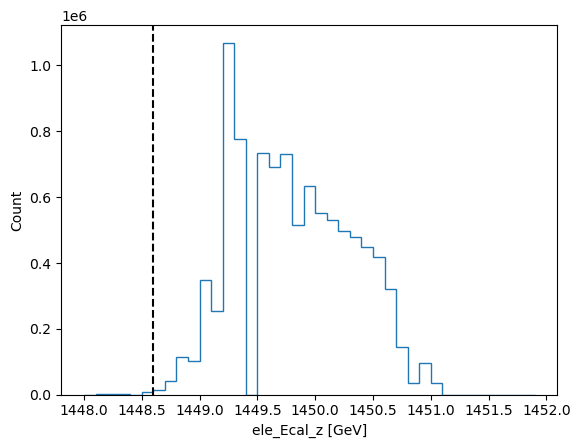

In [13]:
plt.hist(df_data.ele_Ecal_z, bins = np.arange(1448,1452,.1),histtype='step')
plt.axvline(x=QualCuts['ele_Ecal_z_low'], color='k', linestyle='--', label ="selection line")
plt.xlabel('ele_Ecal_z [GeV]')
plt.ylabel('Count')

Text(0, 0.5, 'Count')

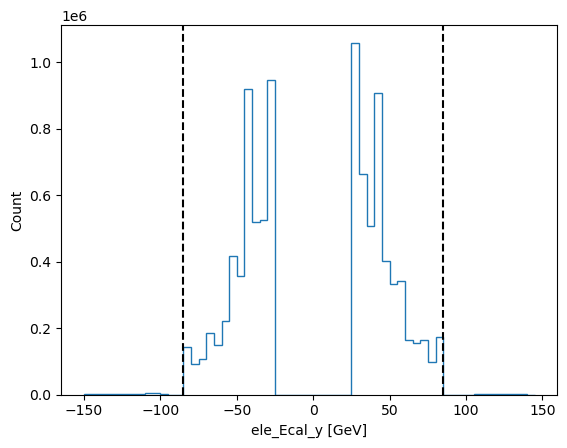

In [14]:
plt.hist(df_data.ele_Ecal_y, bins = np.arange(-150,150,5),histtype='step')
plt.axvline(x=QualCuts['ele_Ecal_y_low'], color='k', linestyle='--', label ="selection line")
plt.axvline(x=QualCuts['ele_Ecal_y_high'], color='k', linestyle='--')
plt.xlabel('ele_Ecal_y [GeV]')
plt.ylabel('Count')

In [15]:

df_data_Qual = df_data[
    (df_data.pos_E_Ecal > QualCuts['pos_E_Ecal_low']) &
    (df_data.pos_Px > QualCuts['pos_Px_low']) &
    ( (df_data.ele_Ecal_z > QualCuts['ele_Ecal_z_low']) | (df_data['ele_Ecal_z'] < 0)) &
    (df_data.ele_Ecal_y > QualCuts['ele_Ecal_y_low']) &
    (df_data.ele_Ecal_y < QualCuts['ele_Ecal_y_high'])
]

df_test_combined_Qual = df_test_combined[
    (df_test_combined.pos_E_Ecal > QualCuts['pos_E_Ecal_low']) &
    (df_test_combined.pos_Px > QualCuts['pos_Px_low']) &
    ( (df_test_combined.ele_Ecal_z > QualCuts['ele_Ecal_z_low']) | (df_test_combined['ele_Ecal_z'] < 0)) &
    (df_test_combined.ele_Ecal_y > QualCuts['ele_Ecal_y_low']) &
    (df_test_combined.ele_Ecal_y < QualCuts['ele_Ecal_y_high'])
]

In [16]:
ANN_selection = np.percentile(test_df_bkg['ANN'], 99.9)


chi2/ndf = 3470.9/98 = 35.417,  p = 0.000e+00


/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_12939/4179217782.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


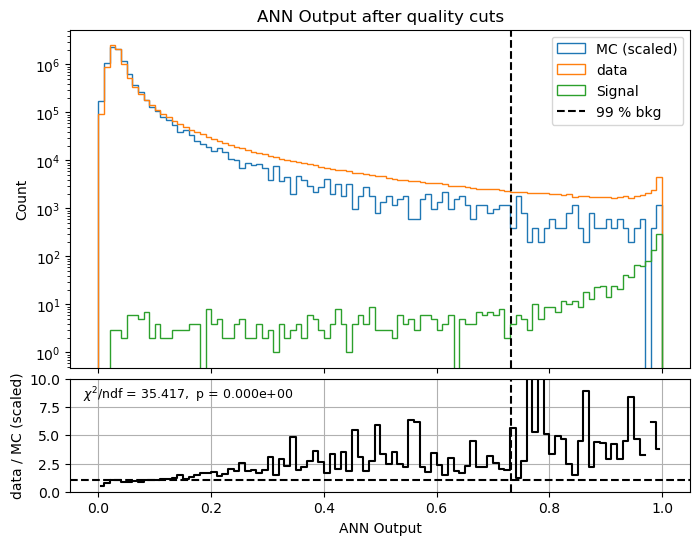

In [17]:
bins = np.arange(0, 1.01, 0.01)

mc_ann_cut   = df_test_combined_Qual['ANN'].to_numpy()
data_ann_cut = df_data_Qual['ANN'].to_numpy()
sig = test_df_phiKK['ANN'].to_numpy()


mc_counts,   edges = np.histogram(mc_ann_cut,   bins=bins)
data_counts, _     = np.histogram(data_ann_cut, bins=bins)

mc_scale = data_counts.sum() / mc_counts.sum()

centers = 0.5 * (edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts * mc_scale,
                  out=np.full_like(data_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

# Chi-squared test (only bins where mc_counts > 0)
mask = mc_counts > 0
chi2_vals = (data_counts[mask] - mc_counts[mask] * mc_scale)**2 / (data_counts[mask] + mc_scale**2 * mc_counts[mask])
chi2  = chi2_vals.sum()
ndf   = mask.sum() - 1  # -1 for normalization constraint
pval  = stats.chi2.sf(chi2, ndf)
print(f"chi2/ndf = {chi2:.1f}/{ndf} = {chi2/ndf:.3f},  p = {pval:.3e}")

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

ax_top.hist(mc_ann_cut,   bins=bins, histtype='step', density=False, weights=np.full(len(mc_ann_cut), mc_scale), label='MC (scaled)')
ax_top.hist(data_ann_cut, bins=bins, histtype='step', density=False, label='data')
ax_top.hist(sig, bins=bins, histtype='step', label='Signal')
ax_top.set_ylabel('Count')
ax_top.set_yscale('log')
ax_top.axvline(x=ANN_selection, color='k', linestyle='--', label='99 % bkg')
ax_top.set_title('ANN Output after quality cuts')
ax_top.legend()

ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.axhline(y=1, color='k', linestyle='--')
ax_bot.grid(True)
ax_bot.set_ylabel('data / MC (scaled)')
ax_bot.axvline(x=ANN_selection, color='k', linestyle='--', label='selection line')
ax_bot.set_xlabel('ANN Output')
ax_bot.set_ylim(0, 10)
ax_bot.text(0.02, 0.95, f'$\\chi^2$/ndf = {chi2/ndf:.3f},  p = {pval:.3e}',
            transform=ax_bot.transAxes, fontsize=9, va='top')

plt.tight_layout()

In [18]:
ANN_selection = np.percentile(test_df_bkg['ANN'], 99.0)


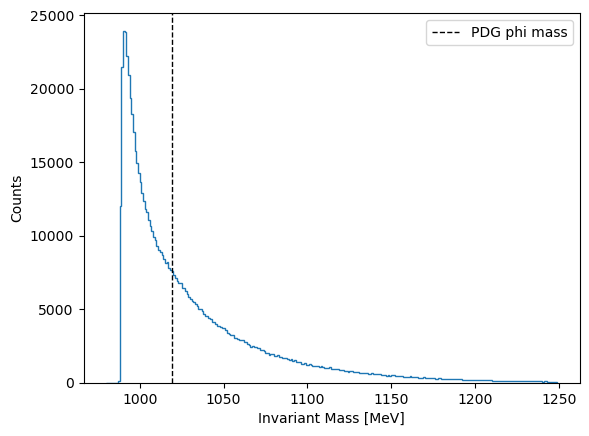

In [19]:
df_data_cut = df_data[df_data['ANN']>ANN_selection].reset_index(drop=True)
x_vals = 1000*df_data_cut.InvM


plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()



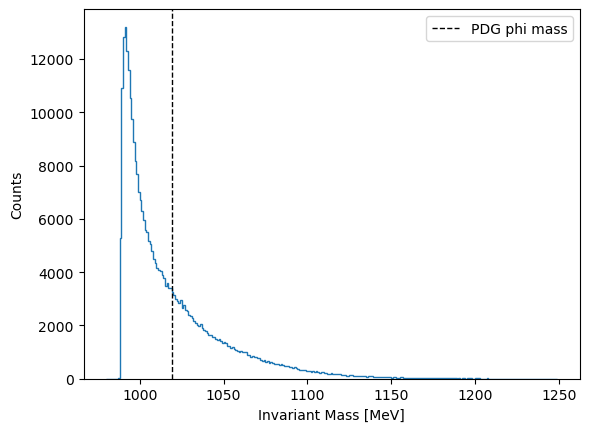

In [20]:
df_data_Qual_cut = df_data_Qual[df_data_Qual['ANN']>ANN_selection].reset_index(drop=True)
x_vals = 1000*df_data_Qual_cut.InvM


plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()



In [23]:
m_K = 0.493677


def calculate_invariant_mass_Ptot(df):
    # Calculate total electron momentum
    df['e_Ptot'] = np.sqrt(df['ele_Px']**2 + df['ele_Py']**2 + df['ele_Pz']**2)
    # Calculate total positron momentum
    df['p_Ptot'] = np.sqrt(df['pos_Px']**2 + df['pos_Py']**2 + df['pos_Pz']**2)
    df['e_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.e_Ptot**2 / (df.e_Ptot**2  + m_K**2) ) )
    df['p_SVT_E_K'] = m_K / np.sqrt ( 1 - ( df.p_Ptot**2 / (df.p_Ptot**2  + m_K**2) ) )
    df['M'] = np.sqrt((df.e_SVT_E_K+df.p_SVT_E_K)**2 - (df.ele_Px+df.pos_Px)**2 - (df.ele_Py+df.pos_Py)**2 - (df.ele_Pz+df.pos_Pz)**2)
    df['Ptot'] = df.e_Ptot + df.p_Ptot

    return df

In [24]:
df_data_cut = calculate_invariant_mass_Ptot(df_data_cut)
df_data_Qual_cut = calculate_invariant_mass_Ptot(df_data_Qual_cut)

In [27]:
df_data_cut.M.to_csv('/Users/mghrear/Desktop/Emrys_phiKK/data_2019_ANN_M.csv', index=False)
df_data_Qual_cut.M.to_csv('/Users/mghrear/Desktop/Emrys_phiKK/data_2019_ANN_Qual_M.csv', index=False)

In [28]:
print(len(df_data_Qual_cut),len(df_data_cut))

317962 757330


# Apply BDT to data

(0.0, 10.0)

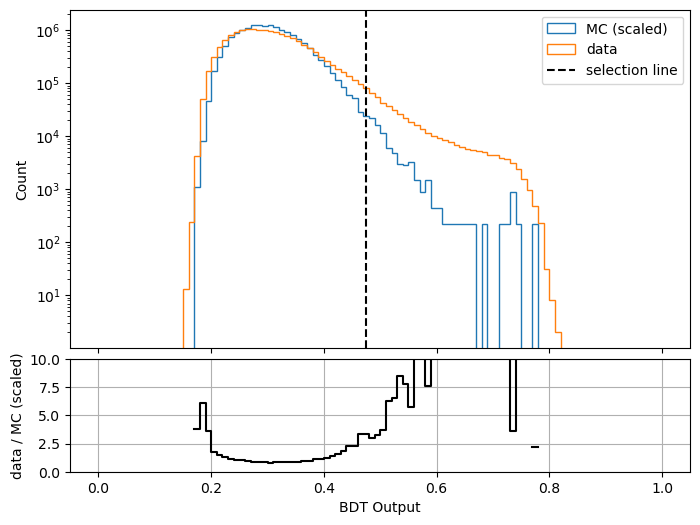

In [60]:
bins = np.arange(0,1.01,0.01)

mc   = df_test_combined['BDT'].to_numpy()
data = df_data['BDT'].to_numpy()


# Use counts (not density) to form the ratio correctly
mc_counts,   edges = np.histogram(mc,   bins=bins)
data_counts, _     = np.histogram(data, bins=bins)

mc_scale = data_counts.sum() / mc_counts.sum()

centers = 0.5*(edges[:-1] + edges[1:])

ratio = np.divide(data_counts, mc_counts * mc_scale,
                  out=np.full_like(data_counts, np.nan, dtype=float),
                  where=mc_counts > 0)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(8, 6),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# --- Top: MC scaled to match data total events ---
ax_top.hist(mc,   bins=bins, histtype='step', density=False, weights=np.full(len(mc), mc_scale), label='MC (scaled)')
ax_top.hist(data, bins=bins, histtype='step', density=False, label='data')
ax_top.axvline(x=BDT_selection, color='k', linestyle='--', label ="selection line")
ax_top.set_ylabel('Count')
ax_top.set_yscale('log')
ax_top.legend()

# --- Bottom: data / scaled MC ratio ---
ax_bot.step(centers, ratio, where='mid', color='k')
ax_bot.grid(True)
ax_bot.set_ylabel('data / MC (scaled)')
ax_bot.set_xlabel('BDT Output')
ax_bot.set_ylim(0, 10)  # adjust as you like

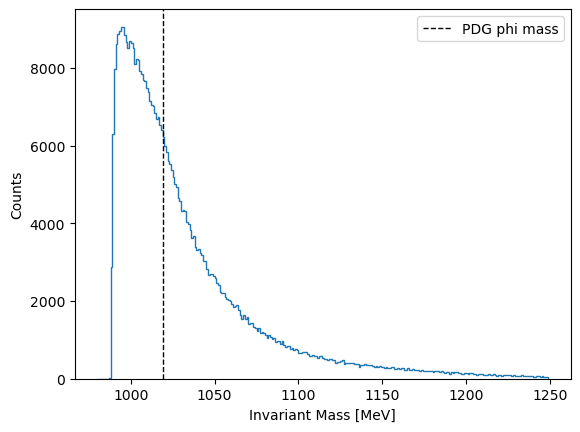

In [61]:
df_data_scaled_cut = df_data[df_data['BDT']>BDT_selection].reset_index(drop=True)
x_vals = 1000*df_data_scaled_cut.InvM


plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Counts')
plt.legend()



In [62]:
np.percentile(df_data['ANN'], 90)

np.float64(0.11881297398374825)